# 05 — `tune`

```
tune.py
=======
Hyperparameter tuning RINGAN untuk YOLO26s (object detection), aman untuk
RTX 4060 Laptop 8 GB VRAM. Menjalankan maksimal 4 eksperimen terkurasi
(bukan tuning otomatis berat), masing-masing dengan fallback OOM batch 8->4->2.

Menggunakan ulang logika teruji dari train.py (cek CUDA, fallback batch,
ekstraksi metrik) agar konsisten.

Jalankan dari ROOT project (Windows):
    python src/tune.py --data dataset/data.yaml
    python src/tune.py --data dataset/data.yaml --dry-run     # tampilkan rencana saja
    python src/tune.py --data dataset/data.yaml --max-exp 2   # jalankan 2 eksperimen pertama

Output (runs/tune/):
  {nama_eksperimen}/            (hasil tiap eksperimen)
  tuning_results.csv            (tabel ringkas semua eksperimen)
  best_model_summary.txt        (pemenang + interpretasi)

Catatan: READ-ONLY terhadap dataset. Hanya model SMALL (yolo26s) yang diizinkan.
```

Notebook ini adalah versi notebook dari [`src/tune.py`](../src/tune.py). Jalankan sel berurutan dari atas.

In [ ]:
DRY_TRAIN: bool = False # Untuk retrain ulang model yang sudah ada, set ke True untuk menghindari proses training ulang yang memakan waktu lama.

## Setup

In [1]:
# === Setup — jalankan sel ini lebih dulu ===
# Menemukan root project, menambahkan src/ ke sys.path, dan pindah (chdir) ke root
# agar semua path relatif (dataset/..., runs/...) berperilaku sama seperti
# menjalankan script dari root project.
import os, sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "src").is_dir() and (d / "dataset").exists():
            return d
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd         :", Path.cwd())

# === Auto-simpan grafik ke presentation_figures/ (otomatis tiap kali di-Run) ===
import matplotlib.pyplot as plt
_FIGDIR = PROJECT_ROOT / "presentation_figures"; _FIGDIR.mkdir(exist_ok=True)
_NB = "05_tune"; _cnt = {"n": 0}
for _old in _FIGDIR.glob(_NB + "_*.png"):
    try: _old.unlink()
    except Exception: pass
_orig_show = getattr(plt, "_orig_show", plt.show); plt._orig_show = _orig_show
def _autosave_show(*a, **k):
    _f = plt.gcf()
    if _f.get_axes():
        _cnt["n"] += 1
        try: _f.savefig(_FIGDIR / (_NB + "_%02d.png" % _cnt["n"]), dpi=130, bbox_inches="tight")
        except Exception: pass
    return _orig_show(*a, **k)
plt.show = _autosave_show

PROJECT_ROOT: D:\ML\test-code\construction-safety-helmet-yolo26
cwd         : D:\ML\test-code\construction-safety-helmet-yolo26


## Apa yang dilakukan notebook ini
**Tujuan:** tuning **ringan & aman untuk GPU 8 GB** — maksimal **4 eksperimen terkurasi** (variasi `lr0`, `weight_decay`, `epochs`), **hanya model small**.

**Alur:** tiap eksperimen → training (fallback OOM 8→4→2) → catat metrik → pilih pemenang dengan kriteria **mAP50-95 → recall → stabilitas & batch lebih besar**. Eksperimen gagal tidak menghentikan proses (CSV ditulis inkremental).

**Output → `runs/tune/`:** folder tiap eksperimen, `tuning_results.csv`, `best_model_summary.txt`.

**Saat presentasi:** default sel Run memakai `--dry-run` (hanya menampilkan rencana) — hapus untuk menjalankan sungguhan. Jelaskan **kenapa dibatasi small-only & 4 eksperimen** (lindungi VRAM 8 GB). Sel kode di bawah = isi lengkap [`src/tune.py`](../src/tune.py).

In [ ]:
from __future__ import annotations

import argparse
import csv
import statistics
import sys
import time
from datetime import datetime
from pathlib import Path

# Pastikan modul train.py (di folder yang sama) bisa diimpor apa pun CWD-nya.
# (path src sudah ditambahkan di sel Setup notebook)
import train as T  # noqa: E402  (reuse: build_batch_candidates, check_cuda_and_gpu, free_cuda, _is_oom_error, extract_metrics)

# 4 eksperimen terkurasi (ringan). imgsz & batch diisi dari parameter umum.
EXPERIMENTS = [
    {"name": "exp_01_yolo26s_baseline_lr001", "model": "yolo26s.pt", "epochs": 50, "lr0": 0.01, "weight_decay": 0.0005},
    {"name": "exp_02_yolo26s_lr0005", "model": "yolo26s.pt", "epochs": 50, "lr0": 0.005, "weight_decay": 0.0005},
    {"name": "exp_03_yolo26s_lr0003", "model": "yolo26s.pt", "epochs": 40, "lr0": 0.003, "weight_decay": 0.0001},
    {"name": "exp_04_yolo26s_low_epoch", "model": "yolo26s.pt", "epochs": 30, "lr0": 0.005, "weight_decay": 0.0001},
]

# Toleransi pemilihan model terbaik.
MAP_TOL = 0.005      # mAP50-95 dianggap "mirip" bila selisih <= ini
RECALL_TOL = 0.01    # recall dianggap "mirip" bila selisih <= ini

# Pola model yang DILARANG (medium/large/xlarge).
FORBIDDEN_MODEL_HINTS = ("m.pt", "l.pt", "x.pt", "yolo26m", "yolo26l", "yolo26x")

CSV_COLUMNS = [
    "experiment_name", "model", "epochs", "final_batch", "imgsz", "lr0",
    "weight_decay", "precision", "recall", "mAP50", "mAP50-95",
    "best_weights_path", "status", "error_message",
]


def _line(char: str = "=", width: int = 70) -> str:
    return char * width


# --------------------------------------------------------------------------- #
# Stabilitas training (untuk tiebreak)
# --------------------------------------------------------------------------- #
def training_stability(save_dir: Path) -> float | None:
    """Std dev mAP50-95 pada 5 epoch terakhir (lebih kecil = lebih stabil)."""
    csv_path = Path(save_dir) / "results.csv"
    if not csv_path.is_file():
        return None
    try:
        with csv_path.open("r", encoding="utf-8") as fh:
            rows = list(csv.DictReader(fh))
    except Exception:
        return None
    vals = []
    for row in rows:
        for k in row:
            if k.strip() == "metrics/mAP50-95(B)":
                try:
                    vals.append(float(row[k]))
                except (TypeError, ValueError):
                    pass
    tail = vals[-5:]
    if len(tail) < 2:
        return None
    return float(statistics.pstdev(tail))


# --------------------------------------------------------------------------- #
# Menjalankan satu eksperimen (tidak pernah melempar exception)
# --------------------------------------------------------------------------- #
def run_experiment(exp: dict, params: dict, exist_ok: bool) -> dict:
    """Latih satu eksperimen dengan fallback OOM. Selalu kembalikan dict hasil."""
    from ultralytics import YOLO

    result = {
        "experiment_name": exp["name"],
        "model": exp["model"],
        "epochs": exp["epochs"],
        "final_batch": None,
        "imgsz": params["imgsz"],
        "lr0": exp["lr0"],
        "weight_decay": exp["weight_decay"],
        "precision": None, "recall": None, "map50": None, "map5095": None,
        "best_weights_path": "",
        "status": "failed",
        "error_message": "",
        "save_dir": "",
        "stability": None,
        "duration_min": None,
    }

    candidates = T.build_batch_candidates(params["batch"])
    # Path absolut agar Ultralytics tidak memindahkan output ke runs/detect/... (lihat train.py).
    abs_project = str(Path(params["project"]).resolve())
    t0 = time.time()

    for attempt, batch in enumerate(candidates, start=1):
        print(f"\n  -> percobaan batch={batch} ({attempt}/{len(candidates)})")
        model = None
        try:
            model = YOLO(exp["model"], task="detect")
            results = model.train(
                data=params["data"], epochs=exp["epochs"], imgsz=params["imgsz"],
                batch=batch, lr0=exp["lr0"], weight_decay=exp["weight_decay"],
                patience=params["patience"], device=params["device"],
                workers=params["workers"], seed=params["seed"], amp=True, cache=False,
                project=abs_project, name=exp["name"], exist_ok=exist_ok,
                plots=True, verbose=False,
            )
            trainer = getattr(model, "trainer", None)
            metrics = T.extract_metrics(results, trainer)
            save_dir = Path(getattr(trainer, "save_dir", Path(params["project"]) / exp["name"]))
            best = Path(getattr(trainer, "best", save_dir / "weights" / "best.pt"))

            result.update({
                "final_batch": batch,
                "precision": metrics.get("precision"),
                "recall": metrics.get("recall"),
                "map50": metrics.get("map50"),
                "map5095": metrics.get("map5095"),
                "best_weights_path": str(best),
                "status": "success",
                "save_dir": str(save_dir),
                "stability": training_stability(save_dir),
                "duration_min": round((time.time() - t0) / 60, 2),
            })
            return result

        except Exception as exc:  # noqa: BLE001
            if T._is_oom_error(exc):
                print(f"     [OOM] batch={batch} kehabisan memori; bersihkan cache & coba lebih kecil.")
                try:
                    del model
                except Exception:
                    pass
                T.free_cuda()
                result["error_message"] = f"CUDA OOM pada batch {batch}"
                if attempt < len(candidates):
                    continue
                result["status"] = "failed_oom"
                result["final_batch"] = batch
                result["error_message"] = f"CUDA OOM pada semua batch {candidates}"
                result["duration_min"] = round((time.time() - t0) / 60, 2)
                return result
            # Error non-OOM: catat & berhenti untuk eksperimen ini (lanjut ke eksperimen lain).
            print(f"     [ERROR] eksperimen gagal (bukan OOM): {type(exc).__name__}: {exc}")
            try:
                del model
            except Exception:
                pass
            T.free_cuda()
            result["status"] = "failed"
            result["final_batch"] = batch
            result["error_message"] = f"{type(exc).__name__}: {exc}"
            result["duration_min"] = round((time.time() - t0) / 60, 2)
            return result

    return result


# --------------------------------------------------------------------------- #
# Pemilihan model terbaik
# --------------------------------------------------------------------------- #
def select_best(results: list[dict]) -> dict | None:
    """Pilih terbaik: mAP50-95 -> recall -> (stabil, batch besar). Pakai toleransi."""
    succ = [r for r in results if r["status"] == "success" and r["map5095"] is not None]
    if not succ:
        return None

    # 1) mAP50-95 tertinggi (grup dalam toleransi)
    best_map = max(r["map5095"] for r in succ)
    grp = [r for r in succ if best_map - r["map5095"] <= MAP_TOL]
    if len(grp) == 1:
        return grp[0]

    # 2) recall tertinggi (grup dalam toleransi)
    best_recall = max((r["recall"] or 0.0) for r in grp)
    grp = [r for r in grp if best_recall - (r["recall"] or 0.0) <= RECALL_TOL]
    if len(grp) == 1:
        return grp[0]

    # 3) training lebih stabil (std kecil) lalu batch lebih besar
    def tiebreak_key(r):
        stab = r["stability"] if r["stability"] is not None else float("inf")
        return (stab, -(r["final_batch"] or 0))
    grp.sort(key=tiebreak_key)
    return grp[0]


# --------------------------------------------------------------------------- #
# Output
# --------------------------------------------------------------------------- #
def _fmt(v, nd=4):
    return round(v, nd) if isinstance(v, (int, float)) else "N/A"


def write_results_csv(path: Path, results: list[dict]) -> None:
    with path.open("w", newline="", encoding="utf-8") as fh:
        w = csv.writer(fh)
        w.writerow(CSV_COLUMNS)
        for r in results:
            w.writerow([
                r["experiment_name"], r["model"], r["epochs"], r["final_batch"],
                r["imgsz"], r["lr0"], r["weight_decay"],
                _fmt(r["precision"]), _fmt(r["recall"]), _fmt(r["map50"]), _fmt(r["map5095"]),
                r["best_weights_path"], r["status"], r["error_message"],
            ])


def build_best_summary(results: list[dict], best: dict | None, params: dict) -> str:
    L: list[str] = []
    L.append(_line())
    L.append("RINGKASAN HYPERPARAMETER TUNING - YOLO26s")
    L.append(_line())
    L.append(f"Waktu       : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    L.append(f"Data        : {params['data']}")
    L.append(f"imgsz       : {params['imgsz']}   batch awal: {params['batch']} (fallback 4,2)   "
             f"patience: {params['patience']}   amp: True")
    n_ok = sum(1 for r in results if r["status"] == "success")
    L.append(f"Eksperimen  : {len(results)} dijalankan, {n_ok} sukses")
    L.append("")

    # Tabel ringkas
    L.append("TABEL HASIL")
    L.append("-" * 70)
    L.append(f"{'experiment':<32}{'batch':>6}{'lr0':>8}{'mAP50-95':>10}{'recall':>8}{'status':>10}")
    for r in results:
        L.append(f"{r['experiment_name']:<32}{str(r['final_batch']):>6}{r['lr0']:>8}"
                 f"{_s(r['map5095']):>10}{_s(r['recall']):>8}{r['status']:>10}")
    L.append("")

    # Pemenang
    L.append("MODEL TERBAIK")
    L.append("-" * 70)
    if best is None:
        L.append("Tidak ada eksperimen yang sukses. Periksa kolom error_message di tuning_results.csv.")
    else:
        L.append(f"Pemenang        : {best['experiment_name']}")
        L.append(f"  model         : {best['model']}")
        L.append(f"  epochs        : {best['epochs']}   final_batch: {best['final_batch']}   "
                 f"lr0: {best['lr0']}   weight_decay: {best['weight_decay']}")
        L.append(f"  precision     : {_s(best['precision'])}")
        L.append(f"  recall        : {_s(best['recall'])}")
        L.append(f"  mAP50         : {_s(best['map50'])}")
        L.append(f"  mAP50-95      : {_s(best['map5095'])}")
        if best.get("stability") is not None:
            L.append(f"  stabilitas    : std(mAP50-95, 5 epoch terakhir)={best['stability']:.4f} (kecil=stabil)")
        L.append(f"  best weights  : {best['best_weights_path']}")
        L.append("")
        L.append("  Dasar pemilihan: mAP50-95 tertinggi -> recall lebih tinggi -> "
                 "training lebih stabil & batch lebih besar.")
    L.append("")

    # Interpretasi
    L.append("INTERPRETASI")
    L.append("-" * 70)
    for note in interpret_tuning(results, best):
        L.append(f"- {note}")
    L.append("")
    L.append(_line())
    return "\n".join(L)


def _s(v):
    return f"{v:.4f}" if isinstance(v, (int, float)) else "N/A"


def interpret_tuning(results: list[dict], best: dict | None) -> list[str]:
    notes: list[str] = []
    succ = [r for r in results if r["status"] == "success" and r["map5095"] is not None]
    failed = [r for r in results if r["status"] != "success"]

    if not succ:
        notes.append("Semua eksperimen gagal — cek error_message (kemungkinan OOM/instalasi).")
        return notes

    # Pengaruh learning rate
    by_lr = sorted(succ, key=lambda r: r["map5095"], reverse=True)
    top = by_lr[0]
    notes.append(f"lr0={top['lr0']} memberi mAP50-95 terbaik ({top['map5095']:.4f}) pada eksperimen "
                 f"'{top['experiment_name']}'.")
    spread = max(r["map5095"] for r in succ) - min(r["map5095"] for r in succ)
    if spread >= 0.03:
        notes.append(f"Performa cukup sensitif terhadap learning rate (rentang mAP50-95 ~{spread:.3f}). "
                     "Fokuskan eksplorasi di sekitar lr0 pemenang.")
    else:
        notes.append(f"Performa relatif tidak sensitif terhadap lr0 ini (rentang mAP50-95 ~{spread:.3f}); "
                     "faktor lain (data/augmentasi) mungkin lebih menentukan.")

    # Pengaruh jumlah epoch
    ep50 = [r for r in succ if r["epochs"] >= 50]
    ep_low = [r for r in succ if r["epochs"] <= 30]
    if ep50 and ep_low:
        best50 = max(r["map5095"] for r in ep50)
        bestlow = max(r["map5095"] for r in ep_low)
        if best50 - bestlow >= 0.02:
            notes.append(f"Menambah epoch membantu (50 epoch: {best50:.3f} vs 30 epoch: {bestlow:.3f}).")
        else:
            notes.append(f"Menambah epoch tidak banyak membantu (50: {best50:.3f} vs 30: {bestlow:.3f}); "
                         "pertimbangkan early stopping / hemat waktu dengan epoch lebih sedikit.")

    # Fallback batch terpakai?
    reduced = [r for r in succ if (r["final_batch"] or 8) < 8]
    if reduced:
        notes.append("Sebagian eksperimen turun ke batch <8 karena OOM — wajar di GPU 8 GB; "
                     "metrik tetap valid namun waktu/efektivitas batch berbeda.")

    if failed:
        notes.append(f"{len(failed)} eksperimen gagal/terlewat (lihat tuning_results.csv).")

    if best is not None:
        notes.append(f"Rekomendasi: pakai '{best['experiment_name']}' sebagai konfigurasi final, "
                     "lalu evaluasi dengan src/evaluate.py pada test set.")
    return notes


# --------------------------------------------------------------------------- #
# Main
# --------------------------------------------------------------------------- #
def validate_model_name(name: str) -> None:
    low = name.lower()
    if any(h in low for h in FORBIDDEN_MODEL_HINTS):
        raise ValueError(f"Model '{name}' dilarang (hanya SMALL diizinkan, mis. yolo26s.pt). "
                         "Tuning ini sengaja ringan untuk GPU 8 GB.")


def parse_args(argv: list[str] | None = None) -> argparse.Namespace:
    p = argparse.ArgumentParser(description="Tuning ringan YOLO26s (maks 4 eksperimen).")
    p.add_argument("--data", default="dataset/data.yaml", help="Path data.yaml (default: dataset/data.yaml).")
    p.add_argument("--imgsz", type=int, default=640)
    p.add_argument("--batch", type=int, default=8, help="Batch awal (fallback ke 4 lalu 2 bila OOM).")
    p.add_argument("--device", default="0", help="0 untuk GPU, 'cpu' untuk CPU.")
    p.add_argument("--workers", type=int, default=4)
    p.add_argument("--patience", type=int, default=15, choices=[10, 15], help="Early stopping (10 atau 15).")
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--project", default="runs/tune", help="Folder output (default runs/tune).")
    p.add_argument("--model", default="yolo26s.pt", help="Hanya model SMALL (default yolo26s.pt).")
    p.add_argument("--max-exp", type=int, default=4, help="Jumlah eksperimen yang dijalankan (maks 4).")
    p.add_argument("--exist-ok", dest="exist_ok", action=argparse.BooleanOptionalAction, default=True)
    p.add_argument("--allow-cpu", action="store_true", help="Izinkan tuning di CPU (sangat lambat).")
    p.add_argument("--dry-run", action="store_true", help="Tampilkan rencana eksperimen lalu keluar (tanpa training).")
    return p.parse_args(argv)


def main(argv: list[str] | None = None) -> int:
    args = parse_args(argv)

    print(_line())
    print("HYPERPARAMETER TUNING RINGAN - YOLO26s (RTX 4060 Laptop 8 GB)")
    print(_line())

    # Validasi model small-only
    try:
        validate_model_name(args.model)
    except ValueError as exc:
        print(f"[ERROR] {exc}")
        return 2

    # Pilih eksperimen (maks 4), terapkan model override ke semua.
    n = max(1, min(args.max_exp, len(EXPERIMENTS)))
    experiments = [dict(e, model=args.model) for e in EXPERIMENTS[:n]]

    params = {
        "data": args.data, "imgsz": args.imgsz, "batch": args.batch,
        "device": args.device, "workers": args.workers, "patience": args.patience,
        "seed": args.seed, "project": args.project,
    }

    print("Rencana eksperimen:")
    for i, e in enumerate(experiments, 1):
        print(f"  {i}. {e['name']:<32} epochs={e['epochs']:<3} lr0={e['lr0']:<6} "
              f"wd={e['weight_decay']:<7} (imgsz={params['imgsz']}, batch={params['batch']} fallback 4/2)")
    print()

    if args.dry_run:
        print("[DRY-RUN] Rencana ditampilkan. Tidak ada training dijalankan.")
        return 0

    # Validasi dataset
    if not Path(args.data).is_file():
        print(f"[ERROR] data.yaml tidak ditemukan: {args.data}")
        return 2

    # 3) Cek CUDA sebelum tuning
    print("Pemeriksaan environment:")
    try:
        device_ok, gpu_name = T.check_cuda_and_gpu(args.device)
    except RuntimeError as exc:
        print(f"[ERROR] {exc}")
        return 2
    if not device_ok:
        if args.allow_cpu:
            print("[PERINGATAN] CUDA tak ada; lanjut di CPU (--allow-cpu) — SANGAT lambat untuk tuning.")
            params["device"] = "cpu"
        else:
            print(f"[ERROR] CUDA tidak tersedia (device={args.device}). Tambahkan --allow-cpu "
                  "(sangat lambat) atau perbaiki instalasi CUDA.")
            return 2

    # Jalankan eksperimen (gagal != stop)
    out_dir = Path(args.project)
    out_dir.mkdir(parents=True, exist_ok=True)
    results: list[dict] = []
    for i, exp in enumerate(experiments, 1):
        print("\n" + _line())
        print(f"EKSPERIMEN {i}/{len(experiments)}: {exp['name']}")
        print(f"  epochs={exp['epochs']} lr0={exp['lr0']} weight_decay={exp['weight_decay']}")
        print(_line())
        try:
            res = run_experiment(exp, params, exist_ok=args.exist_ok)
        except KeyboardInterrupt:
            print("\n[INFO] Tuning dibatalkan oleh pengguna.")
            break
        except Exception as exc:  # safety net — seharusnya tak terjadi
            res = dict(experiment_name=exp["name"], model=exp["model"], epochs=exp["epochs"],
                       final_batch=None, imgsz=params["imgsz"], lr0=exp["lr0"],
                       weight_decay=exp["weight_decay"], precision=None, recall=None,
                       map50=None, map5095=None, best_weights_path="", status="failed",
                       error_message=f"unexpected: {exc}", save_dir="", stability=None, duration_min=None)
        status = res["status"]
        print(f"\n  [{status.upper()}] {exp['name']} -> mAP50-95={_s(res['map5095'])} "
              f"recall={_s(res['recall'])} batch={res['final_batch']}")
        results.append(res)
        # Tulis CSV inkremental agar progres tak hilang bila proses terhenti.
        write_results_csv(out_dir / "tuning_results.csv", results)

    if not results:
        print("[ERROR] Tidak ada eksperimen yang dijalankan.")
        return 1

    # Pilih terbaik & tulis summary
    best = select_best(results)
    summary = build_best_summary(results, best, params)
    (out_dir / "best_model_summary.txt").write_text(summary, encoding="utf-8")

    print("\n")
    print(summary)
    print(f"\nHasil: {out_dir / 'tuning_results.csv'}")
    print(f"Ringkasan terbaik: {out_dir / 'best_model_summary.txt'}")
    return 0

## Jalankan
> Atur **`DRY_TRAIN`** di sel di bawah:
> - `DRY_TRAIN = True` → hanya menampilkan **rencana** (cepat, tanpa melatih).
> - `DRY_TRAIN = False` → **tuning nyata**: melatih 4 eksperimen (~belasan jam, fallback OOM 8→4→2), mengisi `runs/tune/` + semua grafik (termasuk **§e per-epoch**).
>
> Jangan jalankan bersamaan dengan training `03` (rebutan GPU).

In [ ]:
# Toggle mode tuning:
#   DRY_TRAIN = True  -> hanya tampilkan RENCANA eksperimen (cepat, TIDAK melatih)
#   DRY_TRAIN = False -> tuning NYATA: latih 4 eksperimen (~belasan jam di GPU 8 GB)
DRY_TRAIN: bool = False

args = ["--data", "dataset/data.yaml"]
if DRY_TRAIN:
    args.append("--dry-run")
rc = main(args)
print("exit code:", rc)

## Tampilkan hasil & visualisasi

In [2]:
# === Tampilkan hasil tuning (jalankan setelah sel Run, tanpa --dry-run) ===
from pathlib import Path
import pandas as pd

p = Path("runs/tune/tuning_results.csv")
if p.exists():
    display(pd.read_csv(p))
    best = Path("runs/tune/best_model_summary.txt")
    if best.exists():
        print(best.read_text(encoding="utf-8"))
else:
    print("Belum ada hasil tuning — jalankan sel Run (hapus --dry-run) dulu.")

Belum ada hasil tuning — jalankan sel Run (hapus --dry-run) dulu.


## Visualisasi hasil tuning
Grafik dibaca dari `runs/tune/tuning_results.csv` (atau `tuning_results_backup.csv`), jadi tetap tampil walau folder `runs/tune` sudah dibersihkan.

### a. Perbandingan mAP50-95 antar eksperimen (pemenang disorot)

sumber: tuning_results_backup.csv  | 4 eksperimen sukses


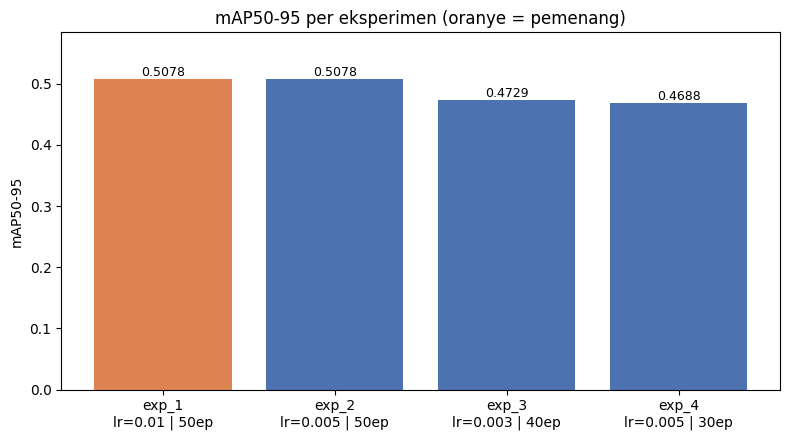

Pemenang: exp_01_yolo26s_baseline_lr001  (mAP50-95=0.5078)


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
src = Path("runs/tune/tuning_results.csv")
if not src.exists():
    src = Path("tuning_results_backup.csv")   # fallback: backup di root
tdf = pd.read_csv(src)
for c in ["precision", "recall", "mAP50", "mAP50-95", "lr0", "epochs"]:
    tdf[c] = pd.to_numeric(tdf[c], errors="coerce")
tdf = tdf[tdf["status"] == "success"].reset_index(drop=True)
labels = [f"exp_{i+1}\nlr={tdf.lr0[i]:g} | {int(tdf.epochs[i])}ep" for i in range(len(tdf))]
win = int(tdf["mAP50-95"].idxmax())
print(f"sumber: {src}  | {len(tdf)} eksperimen sukses")

# a) Bar mAP50-95 — pemenang disorot
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#dd8452" if i == win else "#4c72b0" for i in range(len(tdf))]
b = ax.bar(labels, tdf["mAP50-95"], color=colors)
for bb, v in zip(b, tdf["mAP50-95"]):
    ax.text(bb.get_x()+bb.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_title("mAP50-95 per eksperimen (oranye = pemenang)"); ax.set_ylabel("mAP50-95"); ax.margins(y=0.15)
plt.tight_layout(); plt.show()
print(f"Pemenang: {tdf.loc[win,'experiment_name']}  (mAP50-95={tdf.loc[win,'mAP50-95']:.4f})")

### b. Recall antar eksperimen

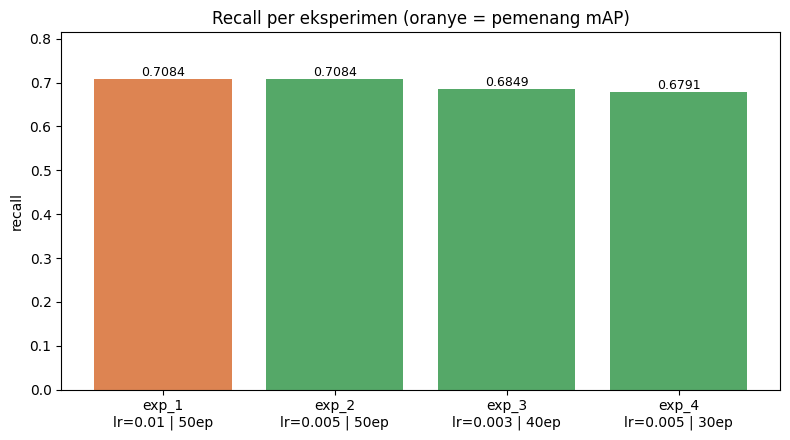

In [4]:
# b) Bar recall antar eksperimen
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#dd8452" if i == win else "#55a868" for i in range(len(tdf))]
b = ax.bar(labels, tdf["recall"], color=colors)
for bb, v in zip(b, tdf["recall"]):
    ax.text(bb.get_x()+bb.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Recall per eksperimen (oranye = pemenang mAP)"); ax.set_ylabel("recall"); ax.margins(y=0.15)
plt.tight_layout(); plt.show()

### c. Semua metrik per eksperimen

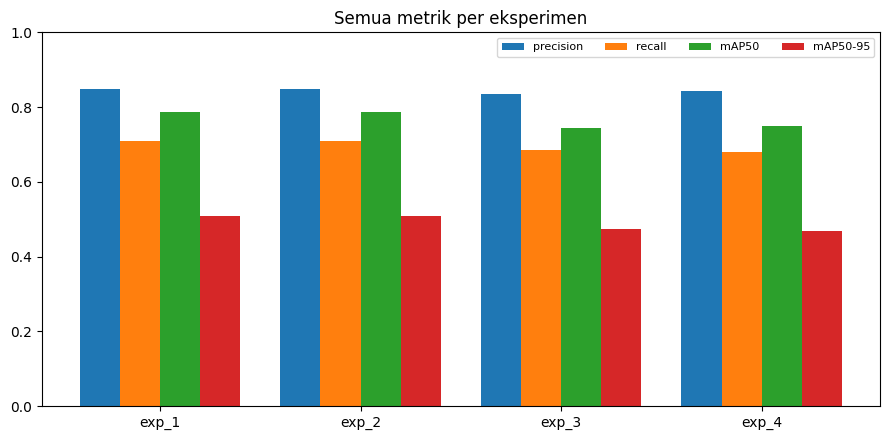

In [5]:
# c) Grouped bar — semua metrik per eksperimen
metrics = ["precision", "recall", "mAP50", "mAP50-95"]
x = np.arange(len(tdf)); w = 0.2
fig, ax = plt.subplots(figsize=(9, 4.5))
for j, m in enumerate(metrics):
    ax.bar(x + (j-1.5)*w, tdf[m], w, label=m)
ax.set_xticks(x); ax.set_xticklabels([f"exp_{i+1}" for i in range(len(tdf))])
ax.set_ylim(0, 1); ax.set_title("Semua metrik per eksperimen"); ax.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()

### d. Pengaruh jumlah epoch — *kenapa* lr0 tak berefek

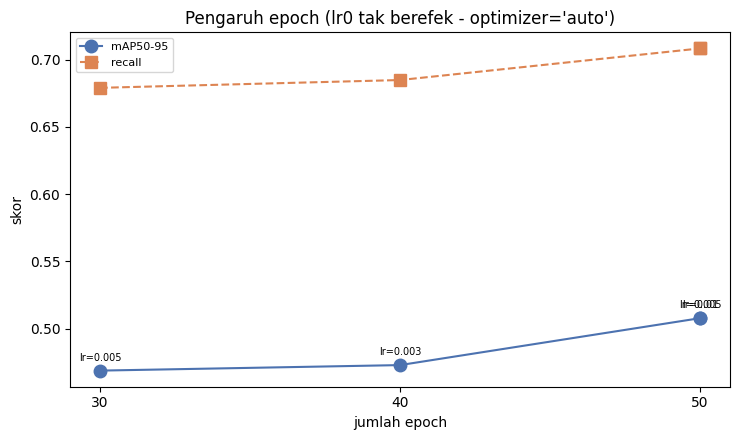

=> 30->50 epoch menaikkan mAP50-95; exp_01(lr0.01) & exp_02(lr0.005) di 50ep IDENTIK -> lr0 diabaikan.


In [6]:
# d) Pengaruh jumlah epoch (lr0 diabaikan karena optimizer='auto')
o = tdf.sort_values("epochs")
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(o["epochs"], o["mAP50-95"], "o-", color="#4c72b0", ms=9, label="mAP50-95")
ax.plot(o["epochs"], o["recall"], "s--", color="#dd8452", ms=8, label="recall")
for _, r in o.iterrows():
    ax.annotate(f"lr={r.lr0:g}", (r.epochs, r["mAP50-95"]), fontsize=7,
                xytext=(0, 7), textcoords="offset points", ha="center")
ax.set_xticks(sorted(o["epochs"].unique()))
ax.set_xlabel("jumlah epoch"); ax.set_ylabel("skor")
ax.set_title("Pengaruh epoch (lr0 tak berefek - optimizer='auto')"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("=> 30->50 epoch menaikkan mAP50-95; exp_01(lr0.01) & exp_02(lr0.005) di 50ep IDENTIK -> lr0 diabaikan.")

### e. Perkembangan metrik **per epoch** — overlay 4 eksperimen
Kurva mAP50-95 & recall **epoch-demi-epoch** untuk tiap eksperimen, ditumpuk dalam satu plot → terlihat mana yang konvergen lebih cepat/tinggi. Dibaca dari `runs/tune/exp_*/results.csv` (perlu hasil tuning; **guarded** bila belum ada).

In [7]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt

exp_dirs = sorted(Path("runs/tune").glob("exp_*")) if Path("runs/tune").exists() else []
runs = []
for d in exp_dirs:
    csv = d / "results.csv"
    if csv.exists():
        df = pd.read_csv(csv); df.columns = [c.strip() for c in df.columns]
        if "epoch" in df.columns and "metrics/mAP50-95(B)" in df.columns:
            runs.append((d.name.replace("yolo26s_", ""), df))
if not runs:
    print("Belum ada data per-epoch tuning (runs/tune/exp_*/results.csv tidak ditemukan).")
    print("=> Jalankan tuning ULANG (hapus --dry-run di sel Run), lalu jalankan sel ini lagi.")
else:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    for name, df in runs:
        ax[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], marker=".", ms=4, label=name)
        if "metrics/recall(B)" in df.columns:
            ax[1].plot(df["epoch"], df["metrics/recall(B)"], marker=".", ms=4, label=name)
    ax[0].set_title("mAP50-95 per epoch (overlay eksperimen)"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mAP50-95"); ax[0].legend(fontsize=8)
    ax[1].set_title("Recall per epoch (overlay eksperimen)"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("recall"); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    print(f"{len(runs)} eksperimen diplot. Kurva yang berimpit = hyperparameter (mis. lr0) tak berefek pada konvergensi.")

Belum ada data per-epoch tuning (runs/tune/exp_*/results.csv tidak ditemukan).
=> Jalankan tuning ULANG (hapus --dry-run di sel Run), lalu jalankan sel ini lagi.


### f. Diagnostik model **pemenang** (confusion matrix, kurva, prediksi val)
Menampilkan plot diagnostik dari folder eksperimen pemenang (`runs/tune/<pemenang>/`) — jadi tak cuma tahu *siapa* yang menang, tapi *sebagus apa* modelnya. Auto-deteksi pemenang dari CSV. **Guarded** (butuh hasil tuning nyata).

In [8]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
src = Path("runs/tune/tuning_results.csv")
if not src.exists(): src = Path("tuning_results_backup.csv")
if not src.exists():
    print("tuning_results.csv / backup tidak ditemukan.")
else:
    df = pd.read_csv(src); df["mAP50-95"] = pd.to_numeric(df["mAP50-95"], errors="coerce")
    df = df[df["status"] == "success"]
    if df.empty:
        print("Tidak ada eksperimen sukses.")
    else:
        win = df.loc[df["mAP50-95"].idxmax(), "experiment_name"]
        wdir = Path("runs/tune") / win
        print(f"Model pemenang: {win}  (mAP50-95={df['mAP50-95'].max():.4f})")
        if not wdir.exists():
            print(f"Folder {wdir} belum ada -> jalankan tuning NYATA (DRY_TRAIN=False) dulu.")
        else:
            shown = False
            for pat in ["confusion_matrix.png", "*PR_curve.png", "*F1_curve.png"]:
                for q in sorted(wdir.glob(pat)):
                    shown = True; print(q.name); display(Image(filename=str(q)))
            vp = sorted(wdir.glob("val_batch*_pred.jpg"))
            if vp:
                shown = True; print("Prediksi pada batch validasi (model pemenang):"); display(Image(filename=str(vp[0])))
            if not shown:
                print(f"Tidak ada plot diagnostik di {wdir}.")

Model pemenang: exp_01_yolo26s_baseline_lr001  (mAP50-95=0.5078)
Folder runs\tune\exp_01_yolo26s_baseline_lr001 belum ada -> jalankan tuning NYATA (DRY_TRAIN=False) dulu.


### g. Overlay **loss per epoch** lintas eksperimen
Kurva box/cls/dfl loss per epoch ditumpuk → lihat apakah ada eksperimen yang divergen / overfit selama tuning. **Guarded** (butuh hasil tuning nyata).

In [9]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
exp_dirs = sorted(Path("runs/tune").glob("exp_*")) if Path("runs/tune").exists() else []
runs = []
for d in exp_dirs:
    csv = d / "results.csv"
    if csv.exists():
        df = pd.read_csv(csv); df.columns = [c.strip() for c in df.columns]
        if "epoch" in df.columns:
            runs.append((d.name.replace("yolo26s_", ""), df))
if not runs:
    print("Belum ada data per-epoch tuning (runs/tune/exp_*/results.csv).")
    print("=> Jalankan tuning NYATA (DRY_TRAIN=False) dulu.")
else:
    losses = [("train/box_loss", "box_loss"), ("train/cls_loss", "cls_loss"), ("train/dfl_loss", "dfl_loss")]
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    for a, (col, title) in zip(ax, losses):
        for name, df in runs:
            if col in df.columns:
                a.plot(df["epoch"], df[col], marker=".", ms=3, label=name)
        a.set_title(title); a.set_xlabel("epoch"); a.set_ylabel("loss"); a.legend(fontsize=7)
    fig.suptitle("Overlay loss train per epoch (lintas eksperimen)")
    plt.tight_layout(); plt.show()
    print("=> Lihat apakah ada eksperimen yang loss-nya divergen / tidak turun mulus.")

Belum ada data per-epoch tuning (runs/tune/exp_*/results.csv).
=> Jalankan tuning NYATA (DRY_TRAIN=False) dulu.


### h. Detail per eksperimen — kurva metrik (small-multiples)
Satu kotak per eksperimen: kurva P/R/mAP50/mAP50-95 per epoch **lengkap** → detail tiap percobaan, tetap berdampingan untuk dibandingkan. **Guarded**.

In [10]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
exp_dirs = sorted(Path("runs/tune").glob("exp_*")) if Path("runs/tune").exists() else []
runs = []
for d in exp_dirs:
    csv = d / "results.csv"
    if csv.exists():
        df = pd.read_csv(csv); df.columns = [c.strip() for c in df.columns]
        if "epoch" in df.columns: runs.append((d.name.replace("yolo26s_", ""), df))
if not runs:
    print("Belum ada data per-epoch tuning (runs/tune/exp_*/results.csv).")
    print("=> Jalankan tuning NYATA (DRY_TRAIN=False) dulu.")
else:
    cols = 2; rows = (len(runs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), squeeze=False); axes = axes.reshape(-1)
    mcols = [("metrics/precision(B)", "precision"), ("metrics/recall(B)", "recall"),
             ("metrics/mAP50(B)", "mAP50"), ("metrics/mAP50-95(B)", "mAP50-95")]
    for ax, (name, df) in zip(axes, runs):
        for col, lab in mcols:
            if col in df.columns: ax.plot(df["epoch"], df[col], label=lab)
        ax.set_title(name); ax.set_xlabel("epoch"); ax.set_ylim(0, 1); ax.legend(fontsize=7)
    for ax in axes[len(runs):]: ax.axis("off")
    fig.suptitle("Detail per eksperimen - kurva metrik per epoch (small-multiples)")
    plt.tight_layout(); plt.show()

Belum ada data per-epoch tuning (runs/tune/exp_*/results.csv).
=> Jalankan tuning NYATA (DRY_TRAIN=False) dulu.


### i. Heatmap perbandingan metrik antar eksperimen
Matriks eksperimen × metrik (warna + nilai); **kotak merah = terbaik per kolom**. Langsung kelihatan siapa unggul di metrik apa. (Terisi dari CSV/backup.)

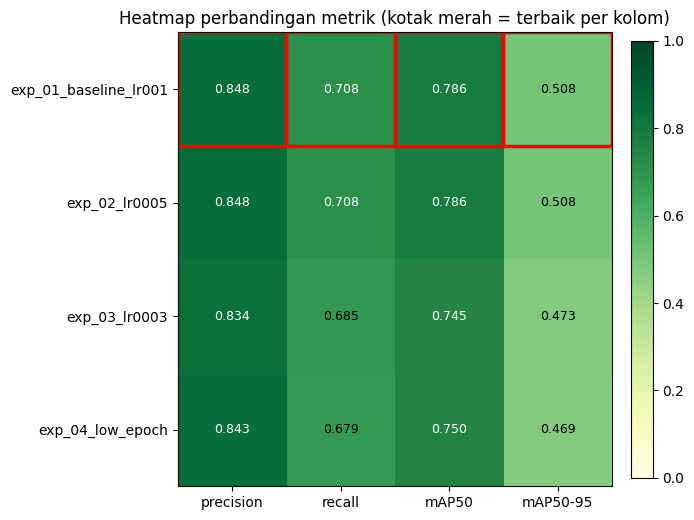

In [11]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
src = Path("runs/tune/tuning_results.csv")
if not src.exists(): src = Path("tuning_results_backup.csv")
if not src.exists():
    print("tuning_results.csv / backup tidak ditemukan.")
else:
    df = pd.read_csv(src)
    metrics = ["precision", "recall", "mAP50", "mAP50-95"]
    for m in metrics: df[m] = pd.to_numeric(df[m], errors="coerce")
    df = df[df["status"] == "success"].reset_index(drop=True)
    labels = [n.replace("yolo26s_", "") for n in df["experiment_name"]]
    M = df[metrics].values
    fig, ax = plt.subplots(figsize=(7, 0.7*len(df) + 2.5))
    im = ax.imshow(M, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels(metrics)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for i in range(len(df)):
        for j in range(len(metrics)):
            v = M[i, j]
            ax.text(j, i, f"{v:.3f}" if v == v else "N/A", ha="center", va="center",
                    color="black" if (v != v or v < 0.7) else "white", fontsize=9)
    for j in range(len(metrics)):
        bi = int(np.nanargmax(M[:, j]))
        ax.add_patch(plt.Rectangle((j-0.5, bi-0.5), 1, 1, fill=False, edgecolor="red", lw=2.5))
    ax.set_title("Heatmap perbandingan metrik (kotak merah = terbaik per kolom)")
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

### j. Confusion matrix tiap eksperimen (berdampingan)
Pola kesalahan per kelas untuk **setiap** eksperimen, disandingkan. **Guarded**.

In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
exp_dirs = sorted(Path("runs/tune").glob("exp_*")) if Path("runs/tune").exists() else []
found = [(d.name.replace("yolo26s_", ""), d / "confusion_matrix.png")
         for d in exp_dirs if (d / "confusion_matrix.png").exists()]
if not found:
    print("Belum ada confusion_matrix per eksperimen (runs/tune/exp_*/confusion_matrix.png).")
    print("=> Jalankan tuning NYATA (DRY_TRAIN=False) dulu.")
else:
    cols = min(2, len(found)); rows = (len(found) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 6*rows), squeeze=False); axes = axes.reshape(-1)
    for ax, (name, q) in zip(axes, found):
        ax.imshow(Image.open(q)); ax.set_title(name, fontsize=10); ax.axis("off")
    for ax in axes[len(found):]: ax.axis("off")
    fig.suptitle("Confusion matrix per eksperimen (berdampingan)")
    plt.tight_layout(); plt.show()

Belum ada confusion_matrix per eksperimen (runs/tune/exp_*/confusion_matrix.png).
=> Jalankan tuning NYATA (DRY_TRAIN=False) dulu.
